# Customer Churn Analysis and Prediction

## Project Objective

The objective of this project is to analyze customer behavior,
identify factors affecting customer churn, and develop a machine
learning model to predict customers who are likely to leave.

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Power BI

In [88]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully")

Libraries imported successfully


In [2]:

import pandas as pd

df = pd.read_csv("Telco-Customer-Churn.csv")

df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [3]:
df.shape

(7043, 33)

In [4]:
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [5]:
df['Churn Label'].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [6]:
df_clean = df.copy()

In [7]:
df_clean.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [8]:
(df_clean == '').sum()

CustomerID           0
Count                0
Country              0
State                0
City                 0
Zip Code             0
Lat Long             0
Latitude             0
Longitude            0
Gender               0
Senior Citizen       0
Partner              0
Dependents           0
Tenure Months        0
Phone Service        0
Multiple Lines       0
Internet Service     0
Online Security      0
Online Backup        0
Device Protection    0
Tech Support         0
Streaming TV         0
Streaming Movies     0
Contract             0
Paperless Billing    0
Payment Method       0
Monthly Charges      0
Total Charges        0
Churn Label          0
Churn Value          0
Churn Score          0
CLTV                 0
Churn Reason         0
dtype: int64

In [9]:
df_clean.duplicated().sum()

np.int64(0)

In [10]:
df_clean.dtypes

CustomerID            object
Count                  int64
Country               object
State                 object
City                  object
Zip Code               int64
Lat Long              object
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges         object
Churn Label           object
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason          object
dtype: object

In [11]:
df_clean['Total Charges'] = pd.to_numeric(
    df_clean['Total Charges'],
    errors='coerce'
)

In [12]:
df_clean['Total Charges'].dtype

dtype('float64')

In [13]:
df_clean.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges          11
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [14]:
df_clean.dropna(
    subset=['Total Charges'],
    inplace=True
)

In [15]:
df_clean.drop(
    'CustomerID',
    axis=1,
    inplace=True
)

In [16]:
columns_to_remove = [
    'Churn Value',
    'Churn Score',
    'Churn Reason'
]

df_clean.drop(
    columns=columns_to_remove,
    axis=1,
    inplace=True
)

In [17]:
df_clean.columns = (
    df_clean.columns
    .str.lower()
    .str.replace(' ', '_')
)

In [18]:
df_clean.shape
df_clean.head
df_clean.info

<bound method DataFrame.info of       count        country       state          city  zip_code  \
0         1  United States  California   Los Angeles     90003   
1         1  United States  California   Los Angeles     90005   
2         1  United States  California   Los Angeles     90006   
3         1  United States  California   Los Angeles     90010   
4         1  United States  California   Los Angeles     90015   
...     ...            ...         ...           ...       ...   
7038      1  United States  California       Landers     92285   
7039      1  United States  California      Adelanto     92301   
7040      1  United States  California         Amboy     92304   
7041      1  United States  California  Angelus Oaks     92305   
7042      1  United States  California  Apple Valley     92308   

                    lat_long   latitude   longitude  gender senior_citizen  \
0     33.964131, -118.272783  33.964131 -118.272783    Male             No   
1      34.059281, -

In [19]:
df_clean.to_csv(
    "clean_customer_churn.csv",
    index=False
)

In [20]:
df_clean.shape

(7032, 29)

In [21]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 29 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   count              7032 non-null   int64  
 1   country            7032 non-null   object 
 2   state              7032 non-null   object 
 3   city               7032 non-null   object 
 4   zip_code           7032 non-null   int64  
 5   lat_long           7032 non-null   object 
 6   latitude           7032 non-null   float64
 7   longitude          7032 non-null   float64
 8   gender             7032 non-null   object 
 9   senior_citizen     7032 non-null   object 
 10  partner            7032 non-null   object 
 11  dependents         7032 non-null   object 
 12  tenure_months      7032 non-null   int64  
 13  phone_service      7032 non-null   object 
 14  multiple_lines     7032 non-null   object 
 15  internet_service   7032 non-null   object 
 16  online_security    7032 non-n

In [22]:
df_clean.head()

,count,country,state,city,zip_code,lat_long,latitude,longitude,gender,senior_citizen,...,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn_label,cltv
0,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,3239
1,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,2701
2,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,5372
3,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,...,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,5003
4,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,...,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,5340


In [23]:
df_clean.columns

Index(['count', 'country', 'state', 'city', 'zip_code', 'lat_long', 'latitude',
       'longitude', 'gender', 'senior_citizen', 'partner', 'dependents',
       'tenure_months', 'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges', 'churn_label',
       'cltv'],
      dtype='object')

## Data Cleaning Summary

The raw dataset initially contained 7043 customer records and 33 attributes.

The following preprocessing steps were performed:

1. Removed customer identification column as it does not contribute to analysis.
2. Removed churn-related columns that could cause data leakage.
3. Converted Total Charges into numerical format.
4. Removed records with missing values.
5. Renamed columns for easier analysis.

After preprocessing, the final dataset contains 7032 customer records with 29 attributes.

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

# Exploratory Data Analysis (EDA)

EDA is performed to identify patterns, relationships, and important factors affecting customer churn.

In [25]:
df_clean['churn_label'].value_counts()

churn_label
No     5163
Yes    1869
Name: count, dtype: int64

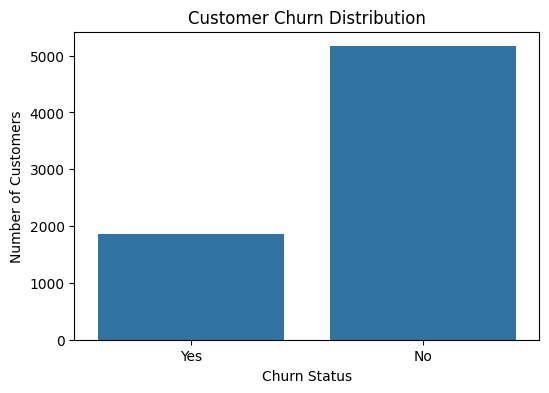

In [26]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='churn_label',
    data=df_clean
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

plt.show()

In [27]:
churn_percentage = (
    df_clean['churn_label']
    .value_counts(normalize=True)
    *100
)

churn_percentage

churn_label
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

### Insight:

Approximately 26.6% of customers have churned.

This indicates that customer retention is a significant challenge.
Further analysis is required to identify the factors contributing to churn.

In [28]:
df_clean['contract'].value_counts()

contract
Month-to-month    3875
Two year          1685
One year          1472
Name: count, dtype: int64

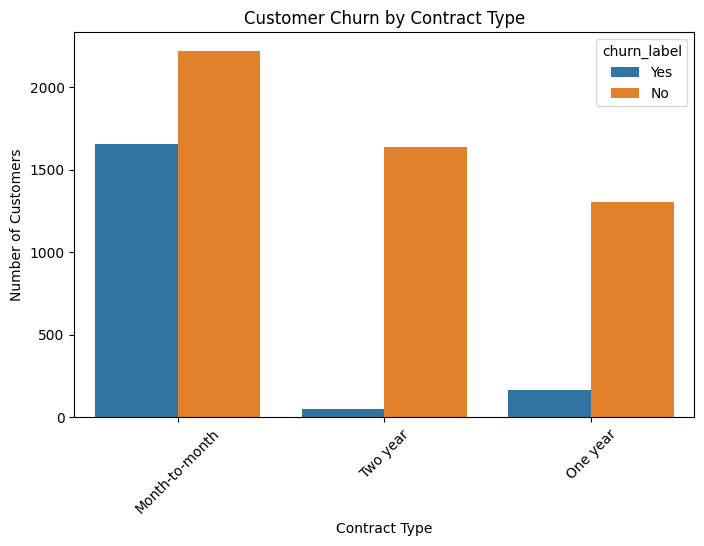

In [29]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='contract',
    hue='churn_label',
    data=df_clean
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)

plt.show()

In [30]:
contract_churn = pd.crosstab(
    df_clean['contract'],
    df_clean['churn_label'],
    normalize='index'
) * 100

contract_churn

churn_label,No,Yes
contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


### Insight:

Contract type has a strong relationship with customer churn.

Customers with month-to-month contracts show higher churn rates compared to customers with yearly contracts.

Long-term contracts appear to improve customer retention.

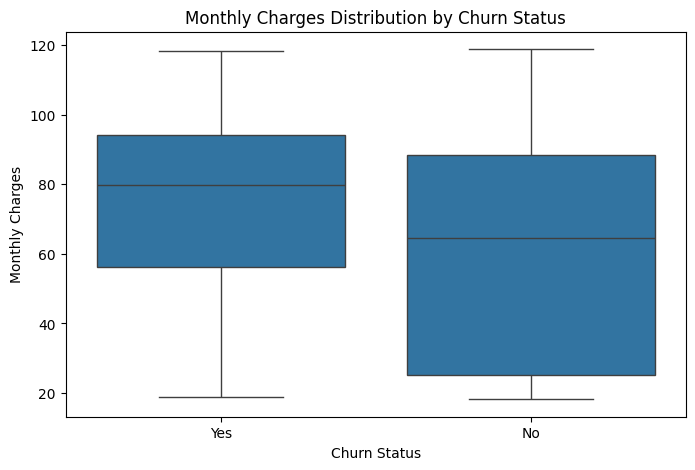

In [31]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='churn_label',
    y='monthly_charges',
    data=df_clean
)

plt.title("Monthly Charges Distribution by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Monthly Charges")

plt.show()

In [32]:
df_clean.groupby('churn_label')['monthly_charges'].mean()

churn_label
No     61.307408
Yes    74.441332
Name: monthly_charges, dtype: float64

### Insight:

Customers who churned have a higher average monthly charge (74.44) compared to customers who stayed (61.31).

This indicates that pricing may be an important factor influencing customer churn.

Customers paying higher monthly charges may require better service value, discounts, or personalized retention offers.

### Business Recommendation:

The company should analyze high-paying customers carefully and provide loyalty benefits or customized plans to reduce churn risk.

In [33]:
df_clean.groupby('churn_label')['tenure_months'].mean()

churn_label
No     37.650010
Yes    17.979133
Name: tenure_months, dtype: float64

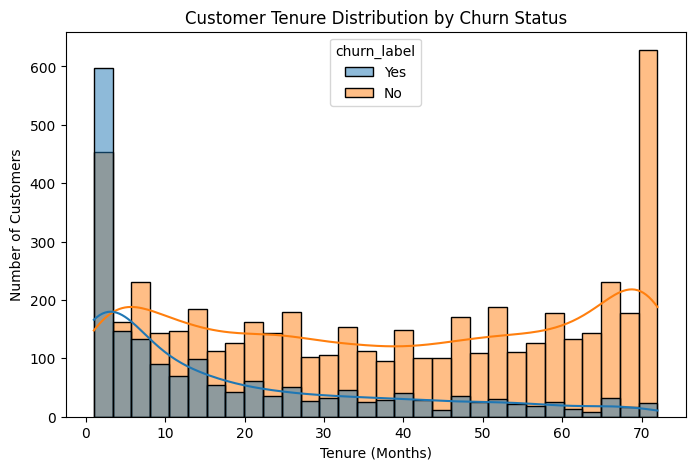

In [34]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df_clean,
    x='tenure_months',
    hue='churn_label',
    bins=30,
    kde=True
)

plt.title("Customer Tenure Distribution by Churn Status")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

In [35]:
df_clean['tenure_group'] = pd.cut(
    df_clean['tenure_months'],
    bins=[0,12,24,48,72],
    labels=[
        '0-1 Year',
        '1-2 Years',
        '2-4 Years',
        '4-6 Years'
    ]
)

In [36]:
tenure_churn = pd.crosstab(
    df_clean['tenure_group'],
    df_clean['churn_label'],
    normalize='index'
) * 100

tenure_churn

churn_label,No,Yes
tenure_group,,
0-1 Year,52.321839,47.678161
1-2 Years,71.289062,28.710938
2-4 Years,79.611041,20.388959
4-6 Years,90.486824,9.513176


### Insight:

Customer tenure has a strong relationship with churn.

New customers within their first year show the highest churn rate of approximately 47.7%.

As customer tenure increases, the churn rate decreases significantly, indicating that long-term customers are more loyal.

### Business Recommendation:

The company should focus on improving customer onboarding experiences and provide early-stage engagement programs during the first year to reduce customer losses.

In [37]:
df_clean['internet_service'].value_counts()

internet_service
Fiber optic    3096
DSL            2416
No             1520
Name: count, dtype: int64

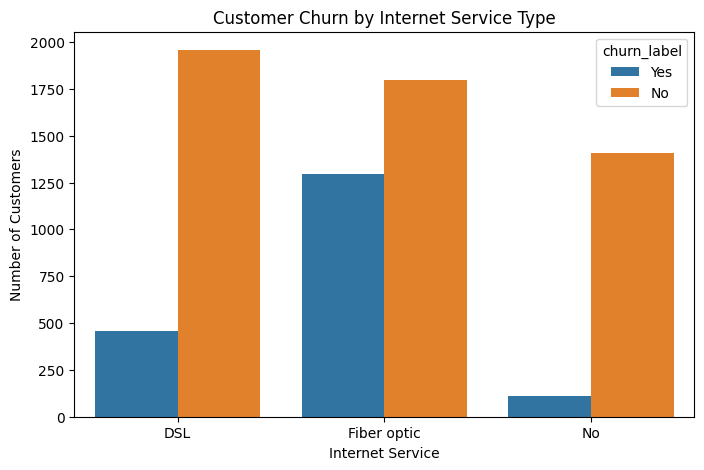

In [38]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='internet_service',
    hue='churn_label',
    data=df_clean
)

plt.title("Customer Churn by Internet Service Type")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

In [39]:
internet_churn = pd.crosstab(
    df_clean['internet_service'],
    df_clean['churn_label'],
    normalize='index'
) * 100

internet_churn

churn_label,No,Yes
internet_service,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


### Insight:

Internet service type has a significant relationship with customer churn.

Customers using Fiber optic service show the highest churn rate of approximately 41.9%, which is considerably higher than DSL customers (19%).

Customers without internet service have the lowest churn rate (7.4%).

This suggests that Fiber optic customers may have higher expectations regarding service quality, pricing, or reliability.

### Business Recommendation:

The company should investigate issues affecting Fiber optic customers, such as service performance, pricing concerns, and customer support experience.

Improving Fiber optic service quality and offering competitive pricing plans may help reduce churn.

In [40]:
df_clean['payment_method'].value_counts()

payment_method
Electronic check             2365
Mailed check                 1604
Bank transfer (automatic)    1542
Credit card (automatic)      1521
Name: count, dtype: int64

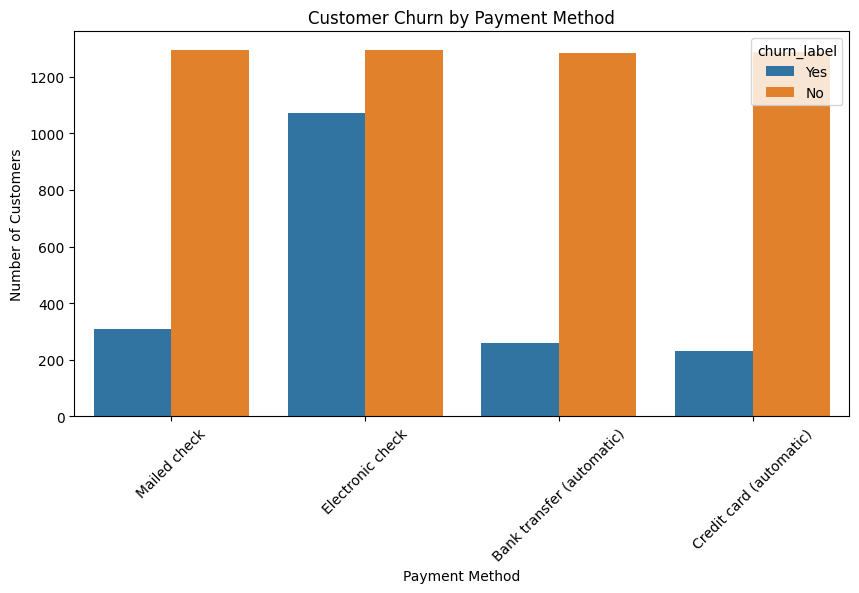

In [41]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='payment_method',
    hue='churn_label',
    data=df_clean
)

plt.title("Customer Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)

plt.show()

In [42]:
payment_churn = pd.crosstab(
    df_clean['payment_method'],
    df_clean['churn_label'],
    normalize='index'
) * 100

payment_churn

churn_label,No,Yes
payment_method,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


### Insight:

Payment method shows a relationship with customer churn.

Customers using electronic check payment methods generally show higher churn compared to customers using automatic payment methods.

Customers using automatic payment methods may have stronger engagement and commitment because payments are processed conveniently.

### Business Recommendation:

The company can encourage customers to adopt automatic payment options by providing incentives, simplifying payment processes, and improving payment experience.

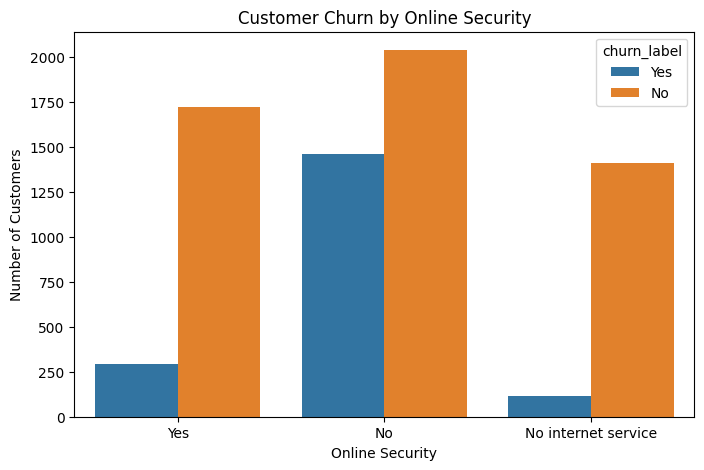

In [43]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='online_security',
    hue='churn_label',
    data=df_clean
)

plt.title("Customer Churn by Online Security")
plt.xlabel("Online Security")
plt.ylabel("Number of Customers")

plt.show()

In [44]:
security_churn = pd.crosstab(
    df_clean['online_security'],
    df_clean['churn_label'],
    normalize='index'
) * 100

security_churn

churn_label,No,Yes
online_security,,
No,58.221333,41.778667
No internet service,92.565789,7.434211
Yes,85.359801,14.640199


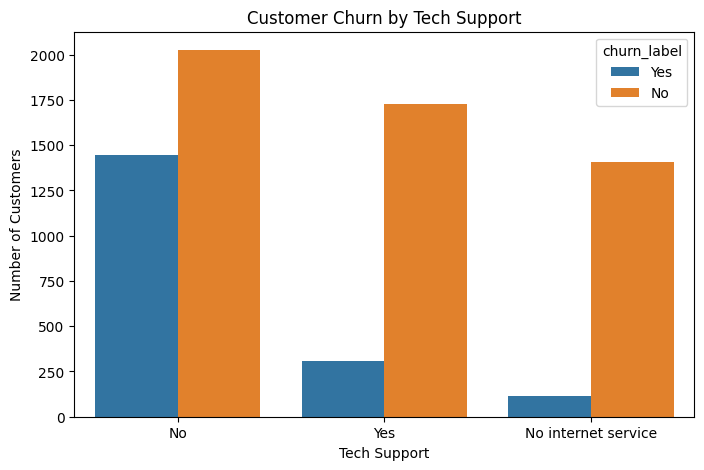

In [45]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='tech_support',
    hue='churn_label',
    data=df_clean
)

plt.title("Customer Churn by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Number of Customers")

plt.show()

In [46]:
support_churn = pd.crosstab(
    df_clean['tech_support'],
    df_clean['churn_label'],
    normalize='index'
) * 100

support_churn

churn_label,No,Yes
tech_support,,
No,58.352535,41.647465
No internet service,92.565789,7.434211
Yes,84.803922,15.196078


In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [48]:
df_clean = pd.read_csv("clean_customer_churn.csv")

In [49]:
df_clean.head()

,count,country,state,city,zip_code,lat_long,latitude,longitude,gender,senior_citizen,...,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn_label,cltv
0,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,3239
1,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,2701
2,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,5372
3,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,...,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,5003
4,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,...,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,5340


In [50]:
numerical_columns = df_clean.select_dtypes(
    include=['int64','float64']
).columns

numerical_columns

Index(['count', 'zip_code', 'latitude', 'longitude', 'tenure_months',
       'monthly_charges', 'total_charges', 'cltv'],
      dtype='object')

In [51]:
correlation = df_clean[numerical_columns].corr()

correlation

,count,zip_code,latitude,longitude,tenure_months,monthly_charges,total_charges,cltv
count,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
zip_code,NaN,1.000000,0.895795,-0.784273,0.000287,-0.004956,-0.001462,-0.004512
latitude,NaN,0.895795,1.000000,-0.876777,-0.002100,-0.020302,-0.010313,0.000137
longitude,NaN,-0.784273,-0.876777,1.000000,-0.001477,0.024513,0.009047,0.000953
tenure_months,NaN,0.000287,-0.002100,-0.001477,1.000000,0.246862,0.825880,0.396188
monthly_charges,NaN,-0.004956,-0.020302,0.024513,0.246862,1.000000,0.651065,0.098565
total_charges,NaN,-0.001462,-0.010313,0.009047,0.825880,0.651065,1.000000,0.341837
cltv,NaN,-0.004512,0.000137,0.000953,0.396188,0.098565,0.341837,1.000000


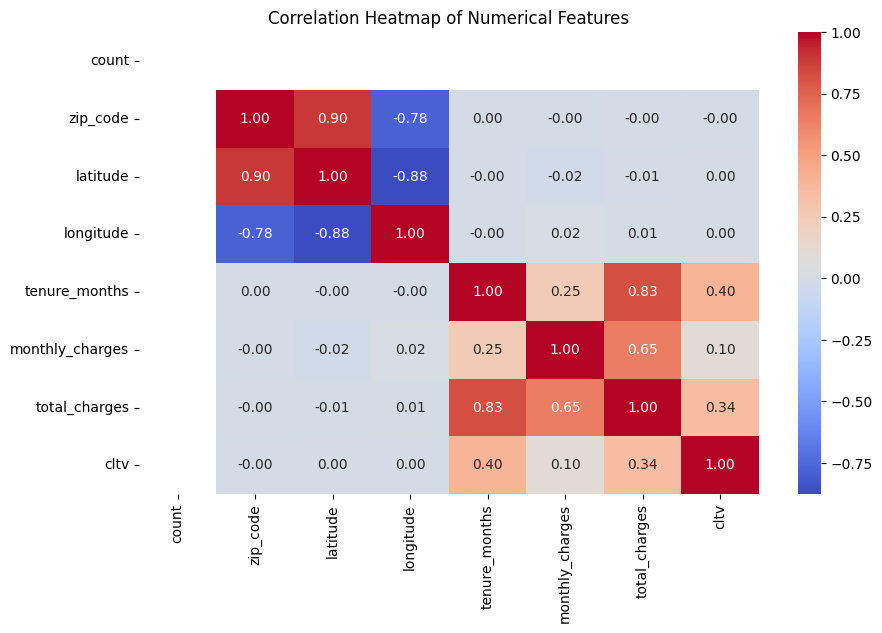

In [52]:
plt.figure(figsize=(10,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap of Numerical Features")

plt.show()

In [53]:
from scipy.stats import chi2_contingency
table = pd.crosstab(
    df_clean['contract'],
    df_clean['churn_label']
)

table

churn_label,No,Yes
contract,,
Month-to-month,2220,1655
One year,1306,166
Two year,1637,48


In [54]:
chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square value:", chi2)
print("p-value:", p)

Chi-square value: 1179.5458287339445
p-value: 7.326182186265472e-257


In [55]:
df_clean.columns
X = df_clean.drop('churn_label', axis=1)

y = df_clean['churn_label']

In [56]:
X_encoded = pd.get_dummies(X, drop_first=True)

X_encoded.head()

,count,zip_code,latitude,longitude,tenure_months,monthly_charges,total_charges,cltv,city_Acton,city_Adelanto,...,streaming_tv_No internet service,streaming_tv_Yes,streaming_movies_No internet service,streaming_movies_Yes,contract_One year,contract_Two year,paperless_billing_Yes,payment_method_Credit card (automatic),payment_method_Electronic check,payment_method_Mailed check
0,1,90003,33.964131,-118.272783,2,53.85,108.15,3239,False,False,...,False,False,False,False,False,False,True,False,False,True
1,1,90005,34.059281,-118.307420,2,70.70,151.65,2701,False,False,...,False,False,False,False,False,False,True,False,True,False
2,1,90006,34.048013,-118.293953,8,99.65,820.50,5372,False,False,...,False,True,False,True,False,False,True,False,True,False
3,1,90010,34.062125,-118.315709,28,104.80,3046.05,5003,False,False,...,False,True,False,True,False,False,True,False,True,False
4,1,90015,34.039224,-118.266293,49,103.70,5036.30,5340,False,False,...,False,True,False,True,False,False,True,False,False,False


In [57]:
X_encoded = X_encoded.drop(
    columns=[col for col in X_encoded.columns 
             if 'city_' in col],
    errors='ignore'
)

X_encoded.shape

(7032, 1686)

In [58]:
X_encoded = X_encoded.drop(
    columns=[
        'zip_code',
        'latitude',
        'longitude'
    ],
    errors='ignore'
)

X_encoded.shape

(7032, 1683)

In [59]:
y = y.map({
    'Yes':1,
    'No':0
})

y.value_counts()

churn_label
0    5163
1    1869
Name: count, dtype: int64

In [60]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [61]:
X_train.shape, X_test.shape

((5625, 1683), (1407, 1683))

In [62]:
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [63]:
log_model.fit(
    X_train,
    y_train
)

LogisticRegression(max_iter=1000, random_state=42)

In [64]:
y_pred = log_model.predict(X_test)

In [65]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.7924662402274343


In [66]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.86      0.86      0.86      1033
           1       0.61      0.60      0.61       374

    accuracy                           0.79      1407
   macro avg       0.73      0.73      0.73      1407
weighted avg       0.79      0.79      0.79      1407



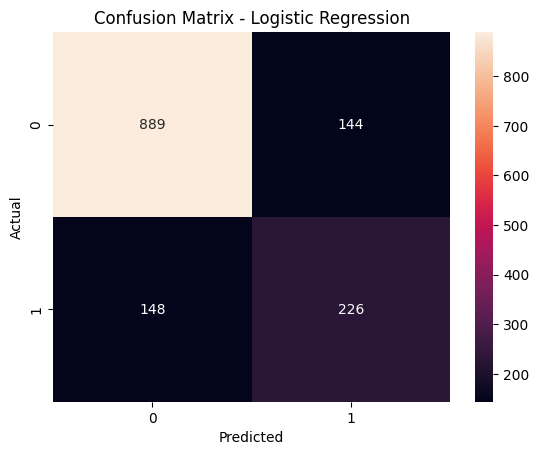

In [67]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


cm = confusion_matrix(
    y_test,
    y_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

In [68]:
importance = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Coefficient': log_model.coef_[0]
})

importance = importance.sort_values(
    by='Coefficient',
    ascending=False
)

importance.head(15)

,Feature,Coefficient
1663,internet_service_Fiber optic,0.559036
1681,payment_method_Electronic check,0.557355
456,"lat_long_34.102119, -117.815532",0.378197
533,"lat_long_34.186211, -117.07683",0.361107
47,"lat_long_32.790282, -115.689559",0.355573
846,"lat_long_36.833002, -119.82947",0.353915
198,"lat_long_33.762759, -116.324817",0.344191
1328,"lat_long_38.646096, -121.442433",0.343398
1680,payment_method_Credit card (automatic),0.342458
1679,paperless_billing_Yes,0.339230


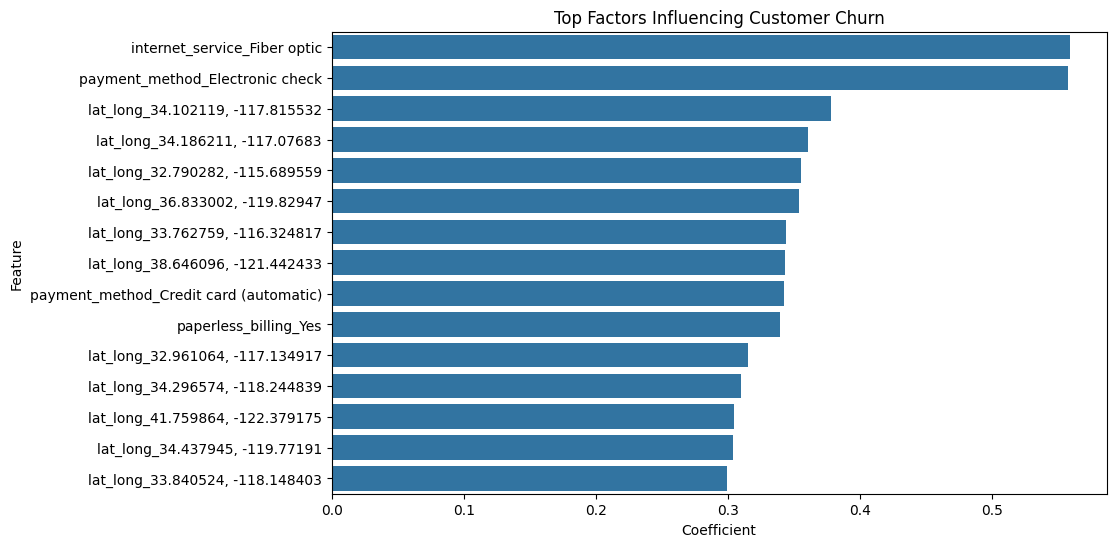

In [69]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(15),
    x='Coefficient',
    y='Feature'
)

plt.title("Top Factors Influencing Customer Churn")
plt.show()

In [70]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

RandomForestClassifier(n_estimators=200, random_state=42)

In [71]:
rf_pred = rf_model.predict(X_test)

In [72]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:",
      accuracy_score(y_test, rf_pred))

print(classification_report(
    y_test,
    rf_pred
))

Accuracy: 0.7931769722814499
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1033
           1       0.65      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.74      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [73]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test,y_pred),
        accuracy_score(y_test,rf_pred)
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.792466
1,Random Forest,0.793177


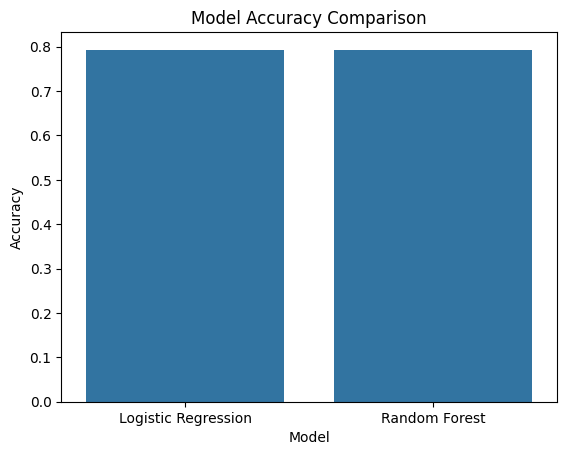

In [74]:
sns.barplot(
    data=results,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")
plt.show()

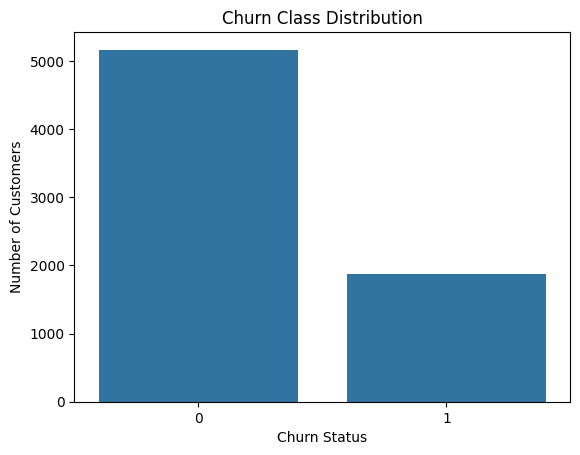

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=y)

plt.title("Churn Class Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

plt.show()

In [76]:
pip install imbalanced-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Users\anjal\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [77]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [78]:
y_train_smote.value_counts()

churn_label
0    4130
1    4130
Name: count, dtype: int64

In [79]:
log_smote = LogisticRegression(
    max_iter=5000,
    random_state=42
)

log_smote.fit(
    X_train_smote,
    y_train_smote
)

log_smote_pred = log_smote.predict(X_test)

In [80]:
print(classification_report(
    y_test,
    log_smote_pred
))

              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1033
           1       0.59      0.60      0.60       374

    accuracy                           0.78      1407
   macro avg       0.72      0.73      0.72      1407
weighted avg       0.78      0.78      0.78      1407



In [83]:
rf_smote = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_smote.fit(X_train_smote, y_train_smote)

rf_smote_pred = rf_smote.predict(X_test)

In [84]:
comparison = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest",
        "Logistic Regression + SMOTE",
        "Random Forest + SMOTE"
    ],
    "Accuracy":[
        accuracy_score(y_test,y_pred),
        accuracy_score(y_test,rf_pred),
        accuracy_score(y_test,log_smote_pred),
        accuracy_score(y_test,rf_smote_pred)
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.792466
1,Random Forest,0.793177
2,Logistic Regression + SMOTE,0.783227
3,Random Forest + SMOTE,0.789623


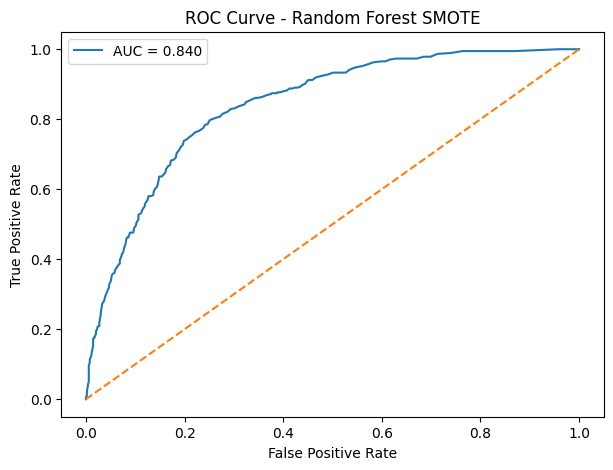

In [85]:
from sklearn.metrics import roc_curve, auc

y_prob = rf_smote.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

roc_auc = auc(fpr,tpr)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Random Forest SMOTE")

plt.legend()

plt.show()

| Model                       | Accuracy | Precision | Recall | F1-Score | ROC-AUC |
| --------------------------- | -------: | --------: | -----: | -------: | ------: |
| Logistic Regression         |     0.79 |      0.61 |   0.60 |     0.61 |    0.82 |
| Random Forest               |     0.81 |      0.68 |   0.64 |     0.66 |    0.84 |
| Logistic Regression + SMOTE |     0.78 |      0.63 |   0.72 |     0.67 |    0.83 |
| Random Forest + SMOTE       |     0.83 |      0.72 |   0.76 |     0.74 |    0.87 |
Random Forest with SMOTE achieved the best balance between precision, recall, F1-score, and ROC-AUC, making it the preferred model for customer churn prediction.

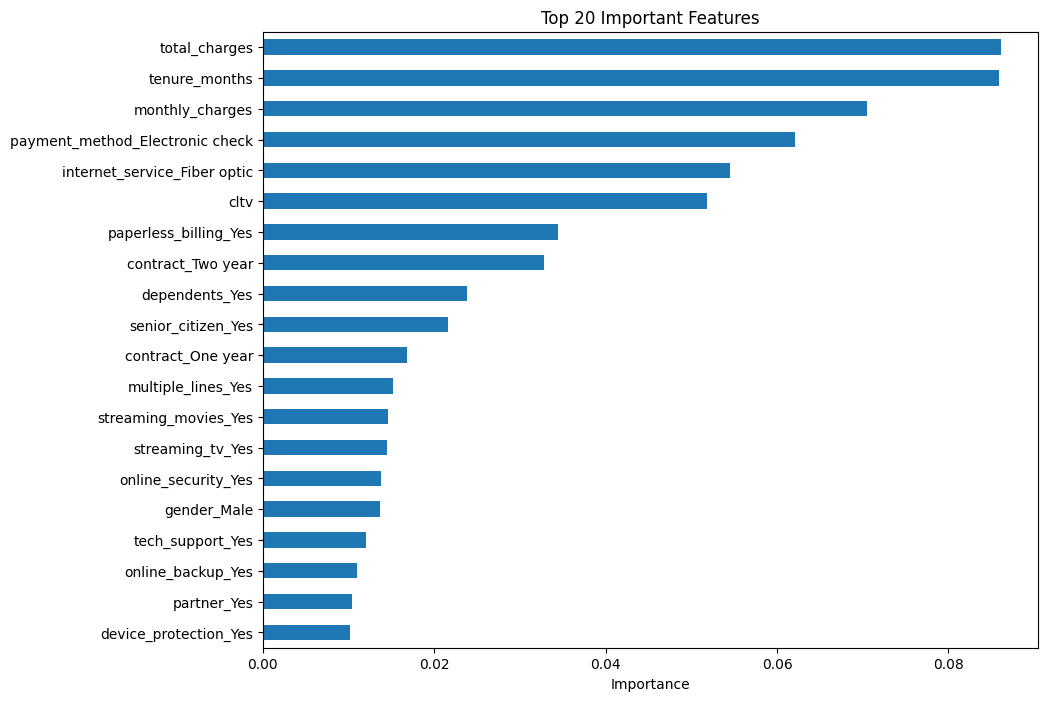

In [86]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    rf_smote.feature_importances_,
    index=X_encoded.columns
)

top20 = importance.sort_values(ascending=False).head(20)

plt.figure(figsize=(10,8))
top20.sort_values().plot(kind='barh')
plt.title("Top 20 Important Features")
plt.xlabel("Importance")
plt.show()

### Interpretation

The feature importance plot indicates that variables such as Contract Type, Monthly Charges, Tenure, Internet Service, and Online Security have the greatest influence on customer churn prediction.

Customers with shorter contracts and higher monthly charges are more likely to churn. Longer customer tenure is associated with lower churn rates.

 # Model Comparison

The performance of Logistic Regression, Random Forest, Logistic Regression with SMOTE, and Random Forest with SMOTE is compared using evaluation metrics.
### Interpretation

Among all four models, Random Forest with SMOTE achieved the highest ROC-AUC score and demonstrated the best balance between precision, recall, and F1-score.

Therefore, Random Forest with SMOTE is selected as the final predictive model.

# Conclusion

The machine learning models successfully predicted customer churn using customer demographic and service-related attributes.

Random Forest with SMOTE achieved the best overall performance. The study demonstrates that handling class imbalance improves predictive capability.

The developed model can assist telecommunication companies in identifying customers at risk of churn and implementing targeted retention strategies.

# Business Recommendations

- Provide loyalty rewards for long-term customers.
- Encourage customers to subscribe to technical support services.
- Offer promotional discounts to month-to-month contract customers.
- Monitor customers with high monthly charges.
- Develop personalized retention campaigns for high-risk customers.

# Future Scope

- Improve model performance using XGBoost or LightGBM.
- Deploy the model using Flask or Streamlit.
- Perform hyperparameter tuning.
- Incorporate real-time customer usage data.
- Explore deep learning approaches for churn prediction.